# 03 - CV Analysis: Peaks And Wave Metrics

This notebook introduces single-CV analysis outputs without making a mechanistic claim. You will load the same CV folder two ways, first with an explicit Fc reference file and then with keyword self-reference, select representative CVs, inspect peak helpers, mark current at a fixed potential, and build a small peak-current table.

The downstream analysis uses the keyword-referenced data so the plotted potentials are already shifted versus Fc/Fc+. Normalization and standardized-current workflows move to notebook 07, where they sit closer to advanced analysis.

## Import eCAT And Set Paths

Later notebooks use the shorter setup pattern introduced in notebook 02. Change `DATA_DIR` when you want to run the same workflow on your own folder.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent


def display_path(path):
    path = Path(path)
    try:
        return str(path.resolve().relative_to(ROOT.resolve()))
    except ValueError:
        return path.name

if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import ecat as e

DATA_DIR = ROOT / "examples" / "data" / "fe_phoh_cv"
EXPORT_DIR = ROOT / "notebooks" / "_outputs"
EXPORT_DIR.mkdir(exist_ok=True)

e.plotting_style("notebook")
print("eCAT version:", getattr(e, "__version__", "unknown"))
print("Example data:", display_path(DATA_DIR))
print("Text files:", len(list(DATA_DIR.glob("*.txt"))))

eCAT version: 0.1.0b2
Example data: examples/data/fe_phoh_cv
Text files: 13


## Load With An Explicit Reference File

Use `reference mode: "file"` when you want every CV in a folder to use one known Fc reference trace. This is the most controlled option when the reference file is clean and representative.

In [2]:
reference_file = DATA_DIR / "MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_to_1V_100mVs.txt"

file_ref_cvs = e.get_data({
    "folder path": str(DATA_DIR),
    "reference mode": "file",
    "reference file": str(reference_file),
    "reference guess": 0.4,
    "reference label": "Fc/Fc+",
    "electrode diameter": 0.3,
    "print": True,
})
file_ref_cvs = e.filter(file_ref_cvs, {"segments": 3}, {"print": False})

Searching recursively through:
 examples/data/fe_phoh_cv
13 .txt files found.

Reference correction:
  Mode: file
  File: MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_to_1V_100mVs.txt
  Midpoint: 0.4665 V
  Usage:
    explicit reference file: 13

[Conditions] Exp Type: CV, Solvent: MeCN, Compounds: 0.1 M TBAPF₆
[Reference] Shift: 0.467, Label: Fc/Fc+, Mode: file, Source: [2]


,Gas,Compounds,Scan Window,Scan Rate,Segments
[0],Ar,1 mM Fe-tpyPY2Me,"[-1.5, 1.5]",100 mV/s,9
[1],Ar,,"[-1.2, 1]",100 mV/s,3
[2],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.2, 1]",100 mV/s,3
[3],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",100 mV/s,3
[4],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",25 mV/s,3
[5],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",500 mV/s,3
[6],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",1 V/s,3
[7],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",50 mV/s,3
[8],CO2,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.2, 1]",100 mV/s,3
[9],CO2,"3 mM Fc, 1 mM Fe-tpyPY2Me, 100 mM PhOH","[-1.2, 1]",100 mV/s,3


## Load With Keyword Self-Reference

Use `reference mode: "keyword"` when Fc is present in many files and each trace can find its own Fc/Fc+ midpoint. Files without the keyword fall back to the folder reference that eCAT finds from the matching Fc file.

In [3]:
cvs = e.get_data({
    "folder path": str(DATA_DIR),
    "reference mode": "keyword",
    "reference keyword": "Fc",
    "reference guess": 0.4,
    "reference label": "Fc/Fc+",
    "electrode diameter": 0.3,
    "print": True,
})
cvs = e.filter(cvs, {"segments": 3}, {"print": False})

Searching recursively through:
 examples/data/fe_phoh_cv
13 .txt files found.

Reference correction:
  Mode: keyword
  Keyword: Fc
  Guess: 0.4 V
  Folder reference: MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_to_1V_100mVs.txt = 0.4665 V
  Usage:
    folder/ancestor reference: 3
    self-referenced successfully: 10

[Conditions] Exp Type: CV, Solvent: MeCN, Compounds: 0.1 M TBAPF₆
[Reference] Label: Fc/Fc+


,Gas,Compounds,Scan Window,Scan Rate,Segments,Reference Shift,Reference Mode,Reference Source
[0],Ar,1 mM Fe-tpyPY2Me,"[-1.5, 1.5]",100 mV/s,9,0.467,folder,[2]
[1],Ar,,"[-1.2, 1]",100 mV/s,3,0.467,folder,[2]
[2],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.2, 1]",100 mV/s,3,0.467,folder,[2]
[3],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",100 mV/s,3,0.467,self,[3]
[4],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",25 mV/s,3,0.467,self,[4]
[5],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",500 mV/s,3,0.466,self,[5]
[6],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",1 V/s,3,0.466,self,[6]
[7],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",50 mV/s,3,0.467,self,[7]
[8],CO2,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.2, 1]",100 mV/s,3,0.467,self,[8]
[9],CO2,"3 mM Fc, 1 mM Fe-tpyPY2Me, 100 mM PhOH","[-1.2, 1]",100 mV/s,3,0.466,self,[9]


## Select A CV Series With `filter`

Use the keyword-referenced `cvs` list for the analysis examples. eCAT filters keep the notebook close to the same public API you will use in lab notebooks.

In [4]:
blank = e.filter(cvs, {
    "gas": "Ar",
    "compounds": ["Fc", "Fe-tpyPY2Me"],
}, {"logic": "AND", "mode": "exclude", "print": False})[0]

fe_ar = e.filter(cvs, {
    "gas": "Ar",
    "compounds": "Fe-tpyPY2Me",
}, {"logic": "AND", "print": False})

co2_cvs = e.filter(cvs, {
    "gas": "CO2",
}, {"print": False})

co2_only = e.filter(co2_cvs, {
    "compounds": "PhOH",
}, {"mode": "exclude", "print": False})[0]

phoh_co2 = e.filter(co2_cvs, {
    "compounds": "PhOH",
}, {"print": False})
co2_titration = [co2_only] + phoh_co2

scan_series = e.filter(fe_ar, {
    "scan window": [-1.7, 1],
}, {"print": False})
scan_series = e.sort(scan_series, "scan rate", {"print": False})

target = phoh_co2[0]

e.show_objects(scan_series, {
    "columns": ["gas", "scan rate", "scan window", "reference shift", "reference mode"],
});

[Conditions] Exp Type: CV, Solvent: MeCN, Gas: Ar, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM Fe-tpyPY2Me, Scan Window: [-1.7, 1], Segments: 3, IR Comp Percent: 100 %
[Reference] Mode: self


,Gas,Scan Window,Scan Rate,Reference Shift
[0],Ar,"[-1.7, 1]",25 mV/s,0.467
[1],Ar,"[-1.7, 1]",50 mV/s,0.467
[2],Ar,"[-1.7, 1]",100 mV/s,0.467
[3],Ar,"[-1.7, 1]",500 mV/s,0.466
[4],Ar,"[-1.7, 1]",1 V/s,0.466


## Inspect One CV With `show`

`show()` gives one tidy Info + Stats table for the selected CV before you run analysis helpers on it.

In [5]:
e.show(target);

,Metric,Value
0,Name,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_100mMPhOH_-1.2_to_1V_100mVs
1,Timestamp,2026-05-07 16:22:24
2,Creation Time,2026-06-08 12:16:55.175656
3,Modification Time,2026-06-08 12:16:55.176443
4,Reference Shift,0.466
5,Reference Label,Fc/Fc+
6,Reference Mode,self
7,Reference Source File,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_100mMPhOH_-1.2_to_1V_100mVs.txt
8,IR Comp Resistance,102 ohm
9,IR Uncomp Resistance,0 ohm


## Plot The Selected CV

A quick plot is a visual check that you selected the trace you meant to analyze. Because the data were reference-shifted during loading, the x-axis is already labeled versus Fc/Fc+.

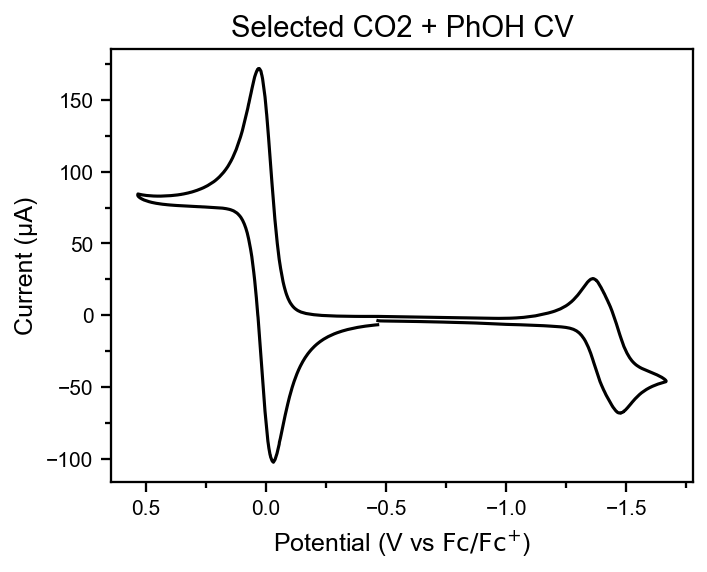

In [6]:
target.plot({"title": "Selected CO2 + PhOH CV"});

## Peak Potential And Peak Current

Start with one selected catalytic CV. Plot the trace once, then let the analysis helpers add diagnostic markers and lines to the same axes.

If you omit `segment` and `guess potential`, single-feature helpers such as `peak_potential()` and `peak_current()` make an exploratory choice: they look for the largest detected feature in the selected data. That default is convenient for inspection, but final analysis should usually specify `segment`, `guess potential`, or `exact potential` so the notebook records the feature you meant to analyze.

Metric,Value
Ep,-1.474 V


Metric,Value
Ep,-1.474 V
ip,-61.68 μA


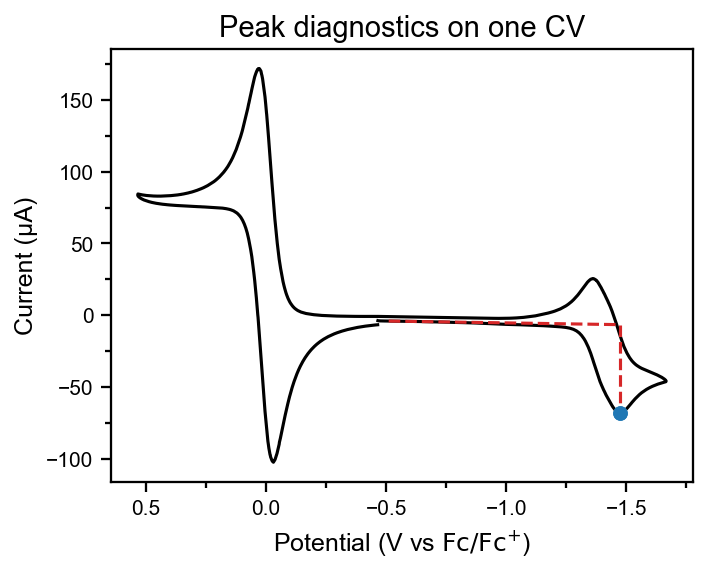

In [7]:
ax = target.plot({"title": "Peak diagnostics on one CV"})

peak_potential = target.peak_potential({
    "segment": 1,
    "guess potential": -1.5,
    "plot CV": False,
})

peak_current = target.peak_current({
    "segment": 1,
    "guess potential": -1.5,
    "plot CV": False,
})

# peak_current.axes.figure.savefig(EXPORT_DIR / "peak_current_analysis.png", dpi=300, bbox_inches="tight")

## Current At A Chosen Potential

Use `current_at_potential()` when you care about the current at one chosen potential rather than the automatically detected peak. The helper finds the nearest measured point in the selected segment, marks it on the plot, and returns a small result table.

Here the chosen potential is `-1.5 V`. Try changing the potential, removing `"segment"` to report all segments, setting `"plot": False` to calculate without drawing, or setting `"print": False` to suppress the table.

Metric,Value
Potential,-1.5 V
Current,-65.59 μA


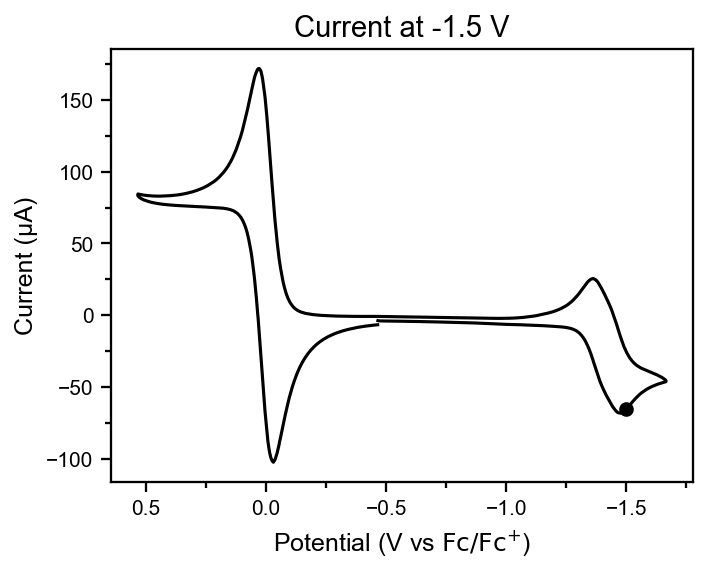

In [8]:
ax = target.plot({"title": "Current at -1.5 V"})

current_at_feature = target.current_at_potential(-1.5, {
    "segment": 1,
    "plot CV": False,
})

## Half-Peak Potential And Peak Info

`half_peak_potential()` reports the potential halfway between the tangent baseline and the selected peak current. `peak_info()` bundles the related single-peak values into one table: Ep, ip, Ep/2, and Δ(Ep - Ep/2).

These are still single-feature helpers, so their no-guess defaults follow the same exploratory behavior as `peak_current()`: eCAT analyzes the largest detected feature in the selected data. In this example, the options are explicit because the catalytic feature is the one we want to document.

Metric,Value
Ep/2,-1.373 V
Δ(Ep - Ep/2),-0.101 V
Ep,-1.474 V
ip,-61.68 μA


Metric,Value
Ep,-1.474 V
ip,-61.68 μA
Ep/2,-1.373 V
Δ(Ep - Ep/2),-0.101 V


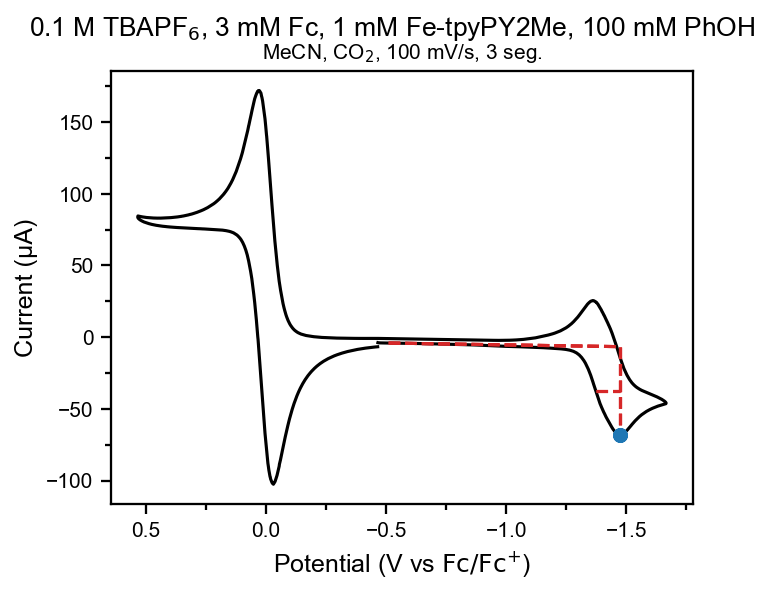

In [9]:
half_peak = target.half_peak_potential({
    "segment": 1,
    "guess potential": -1.5,
})

peak_summary = target.peak_info({
    "segment": 1,
    "guess potential": -1.5,
    "plot CV": False,
})

## Half-Wave Potential And Wave Info

Use `half_wave_potential()` and `wave_info()` when you have paired forward/reverse peaks for the same wave. These helpers are intentionally smart, but they make a different default assumption than the single-feature helpers: if `segments` is omitted, eCAT starts with segment `1` and pairs it with segment `2`.

That `[1, 2]` default is useful for quick inspection of simple forward/reverse CVs, but paired-wave analysis is more assumption-heavy than single-peak analysis. For real analysis, specify `segments` and add `guess potential` when needed so eCAT targets the redox couple you intend.

The blue markers show the two peak potentials used for the paired wave. The blue dashed line connects those peaks and marks the half-wave potential. The red dashed tangent and construction lines come from the peak-current diagnostic: they show the baseline/tangent correction used to estimate peak current and half-peak position.

Here `half_wave_potential()` is given `"segments": [2, 3]` explicitly so the example calls out the Fc/Fc+ forward/reverse pair. In the `wave_info()` call, `segments` is intentionally omitted to show the paired-wave default. Start with this minimal version, then play with the omitted options: add `"segments"` to choose a different pair, add `"guess potential"` if the automatic peak choice grabs the wrong feature, set `"plot": False` to calculate without drawing, set `"print": False` to suppress the summary table, or set `"plot CV": False` when you already drew the trace and only want diagnostics added.

## Build A Small Peak Table

For a series, draw the CVs once with `multiplot()`, then let `peak_current()` add only the diagnostic lines and markers. This keeps the overlay readable while the loop collects the result values you actually need.

The highest-concentration trace does not have a true local peak. When `peak_potential()` cannot find an extremum, `peak_current()` uses the `peak fallback` option; by default, `peak fallback` is `"highest current"`, meaning eCAT uses the largest absolute current in the selected segment. For stricter analysis, set `"peak fallback": None`; to force the point nearest your guess, set `"peak fallback": "guess potential"`.

,name,scan_rate_V_per_s,Ep_V,ip_A
0,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_100mM...,0.1,-1.474,-0.000062
1,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_560mM...,0.1,-1.512,-0.000105
2,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_1MPhO...,0.1,-1.550,-0.000173
3,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_2.8MP...,0.1,-1.710,-0.000161


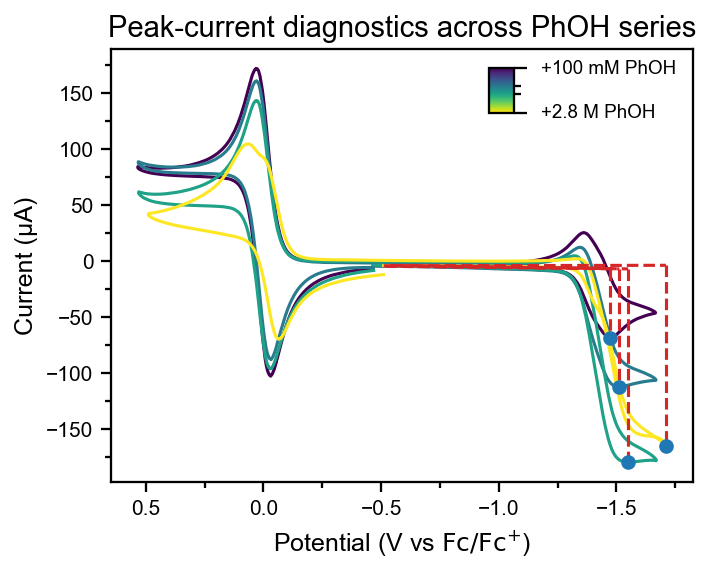

In [10]:
import pandas as pd

ax = e.multiplot(phoh_co2, {"title": "Peak-current diagnostics across PhOH series"})

peak_rows = []
for obj in phoh_co2:
    result = obj.peak_current({
        "segment": 1,
        "guess potential": -1.5,
        "print": False,
        "plot CV": False,
    })
    peak_rows.append({
        "name": obj.name,
        "scan_rate_V_per_s": obj.scan_rate,
        "Ep_V": float(result["Ep"]),
        "ip_A": float(result["ip"]),
    })
peak_table = pd.DataFrame(peak_rows)
peak_table